# Ejercicio: Red Neuronal desde cero y con Keras

En este notebook vas a:
- Entender cómo funciona una neurona artificialmente
- Implementar **forward pass** y **backpropagation** a mano (en NumPy)
- Construir una red con **Keras/TensorFlow** y entrenarla
- Visualizar el entrenamiento, los errores y las predicciones

**Problema:** Clasificación binaria — predecir si un tumor es maligno o benigno.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
print('TensorFlow version:', tf.__version__)
print('Librerías cargadas correctamente ✓')

TensorFlow version: 2.21.0
Librerías cargadas correctamente ✓


---
## Parte 1 — Una neurona desde cero con NumPy

Antes de usar Keras, entendamos qué hace una neurona matemáticamente.

Una neurona calcula:
$$\hat{y} = \sigma(w \cdot x + b)$$

Donde $\sigma$ es la función de activación (usaremos **sigmoid** para clasificación binaria).

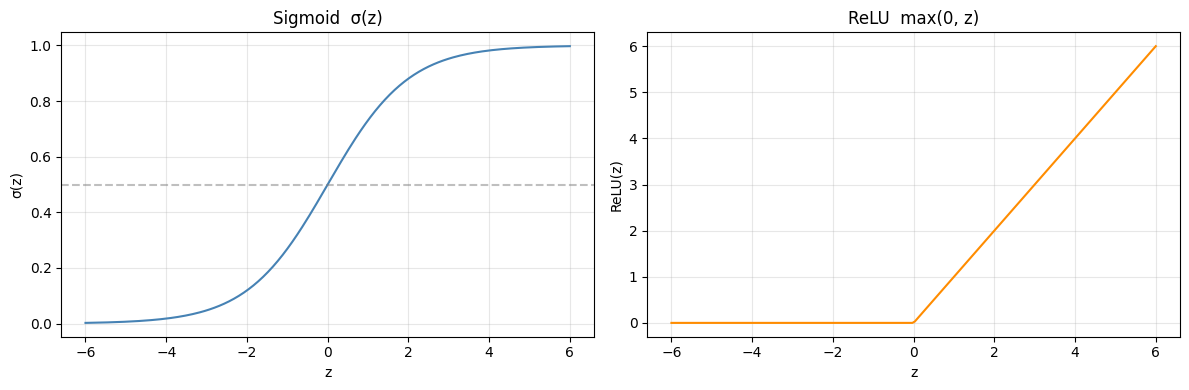

In [2]:
# Funciones de activación
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

# Visualizar las funciones de activación
z = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(z, sigmoid(z), color='steelblue')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sigmoid  σ(z)')
axes[0].set_xlabel('z')
axes[0].set_ylabel('σ(z)')
axes[0].grid(alpha=0.3)

axes[1].plot(z, relu(z), color='darkorange')
axes[1].set_title('ReLU  max(0, z)')
axes[1].set_xlabel('z')
axes[1].set_ylabel('ReLU(z)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Red neuronal de 2 capas en NumPy

Arquitectura: **input → capa oculta (ReLU) → capa de salida (Sigmoid)**

Implementaremos:
- `forward_pass` → calcula la predicción
- `compute_loss` → Binary Cross-Entropy
- `backward_pass` → calcula gradientes
- `update_params` → descenso de gradiente

In [3]:
class RedNeuronal:
    def __init__(self, n_input, n_hidden, n_output=1, lr=0.01):
        """Inicializa pesos con He initialization."""
        self.lr = lr
        # Capa oculta
        self.W1 = np.random.randn(n_input, n_hidden) * np.sqrt(2 / n_input)
        self.b1 = np.zeros((1, n_hidden))
        # Capa de salida
        self.W2 = np.random.randn(n_hidden, n_output) * np.sqrt(2 / n_hidden)
        self.b2 = np.zeros((1, n_output))

    def forward(self, X):
        """Propagación hacia adelante."""
        self.z1 = X @ self.W1 + self.b1        # pre-activación capa 1
        self.a1 = relu(self.z1)                 # activación capa 1 (ReLU)
        self.z2 = self.a1 @ self.W2 + self.b2  # pre-activación capa 2
        self.a2 = sigmoid(self.z2)              # salida (prob entre 0 y 1)
        return self.a2

    def compute_loss(self, y_true, y_pred):
        """Binary Cross-Entropy Loss."""
        eps = 1e-8
        m = y_true.shape[0]
        loss = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
        return loss

    def backward(self, X, y):
        """Backpropagation — calcula gradientes."""
        m = X.shape[0]
        # Gradiente capa de salida
        dz2 = self.a2 - y.reshape(-1, 1)
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.mean(dz2, axis=0, keepdims=True)
        # Gradiente capa oculta
        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_deriv(self.z1)
        dW1 = (X.T @ dz1) / m
        db1 = np.mean(dz1, axis=0, keepdims=True)
        # Actualizar pesos
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y, epochs=500, verbose=True):
        self.losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            self.backward(X, y)
            if verbose and epoch % 100 == 0:
                print(f'Epoch {epoch:4d} | Loss: {loss:.4f}')
        return self

    def predict(self, X, threshold=0.5):
        probs = self.forward(X)
        return (probs >= threshold).astype(int).flatten()

print('Clase RedNeuronal definida ✓')

Clase RedNeuronal definida ✓


### 1.3 Cargar datos y entrenar la red NumPy

In [4]:
# Dataset: Breast Cancer Wisconsin
data = load_breast_cancer()
X, y = data.data, data.target

print(f'Muestras: {X.shape[0]}, Features: {X.shape[1]}')
print(f'Clases: {data.target_names}  (0=maligno, 1=benigno)')
print(f'Distribución: {dict(zip(*np.unique(y, return_counts=True)))}')

# Split y escalado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Entrenar red NumPy
red = RedNeuronal(n_input=X_train_s.shape[1], n_hidden=16, lr=0.05)
red.fit(X_train_s, y_train, epochs=500)

Muestras: 569, Features: 30
Clases: ['malignant' 'benign']  (0=maligno, 1=benigno)
Distribución: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
Epoch    0 | Loss: 0.8184
Epoch  100 | Loss: 1.8701
Epoch  200 | Loss: 2.3661
Epoch  300 | Loss: 2.7041
Epoch  400 | Loss: 2.9574


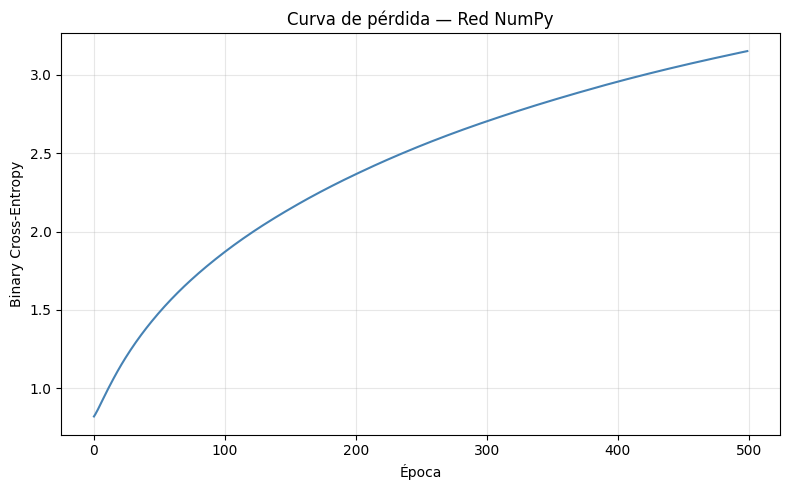


=== Métricas en test (Red NumPy) ===
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [5]:
# Curva de pérdida
plt.plot(red.losses, color='steelblue')
plt.title('Curva de pérdida — Red NumPy')
plt.xlabel('Época')
plt.ylabel('Binary Cross-Entropy')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Métricas
y_pred_numpy = red.predict(X_test_s)
print('\n=== Métricas en test (Red NumPy) ===')
print(classification_report(y_test, y_pred_numpy, target_names=data.target_names))

---
## Parte 2 — Red Neuronal con Keras

Ahora construimos la misma arquitectura pero usando la API de alto nivel de Keras.

### 2.1 Definir la arquitectura

In [6]:
def build_model(n_input, hidden_units=[32, 16], dropout_rate=0.3):
    model = keras.Sequential(name='red_neuronal')
    model.add(layers.Input(shape=(n_input,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))  # salida binaria
    return model

model = build_model(n_input=X_train_s.shape[1])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "red_neuronal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Entrenar el modelo

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

historia = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6676 - loss: 0.6195 - val_accuracy: 0.8901 - val_loss: 0.4869
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8242 - loss: 0.5006 - val_accuracy: 0.9011 - val_loss: 0.3874
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8626 - loss: 0.4074 - val_accuracy: 0.9121 - val_loss: 0.3130
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8874 - loss: 0.3150 - val_accuracy: 0.9341 - val_loss: 0.2593
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9093 - loss: 0.2574 - val_accuracy: 0.9341 - val_loss: 0.2208
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9121 - loss: 0.2301 - val_accuracy: 0.9560 - val_loss: 0.1928
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9121 - loss: 0.2056 - val_accuracy: 0.9560 - val_loss: 0.1713
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9258 - loss: 0.1959 - val_accuracy: 0.9560 - 

### 2.3 Curvas de entrenamiento

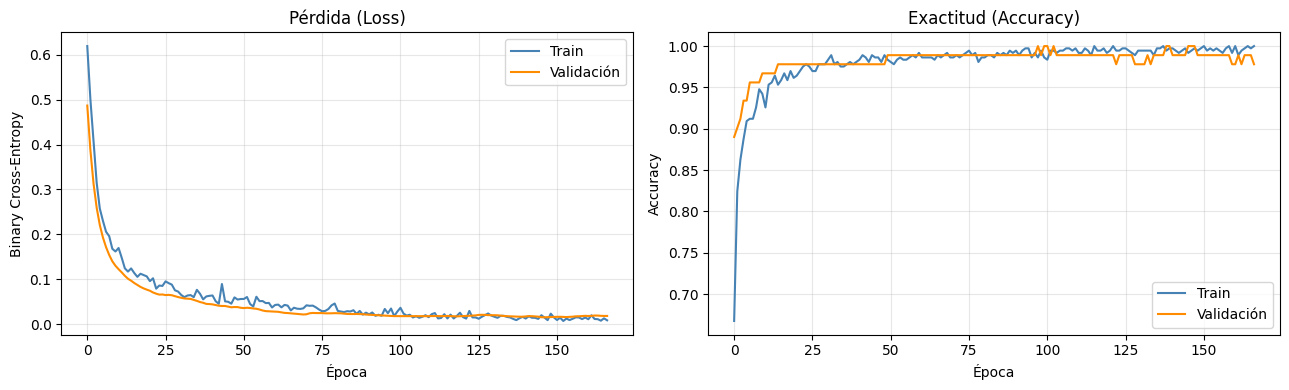

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(historia.history['loss'], label='Train', color='steelblue')
axes[0].plot(historia.history['val_loss'], label='Validación', color='darkorange')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(historia.history['accuracy'], label='Train', color='steelblue')
axes[1].plot(historia.history['val_accuracy'], label='Validación', color='darkorange')
axes[1].set_title('Exactitud (Accuracy)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4 Evaluación en test

In [9]:
loss_test, acc_test = model.evaluate(X_test_s, y_test, verbose=0)
print(f'Loss en test:     {loss_test:.4f}')
print(f'Accuracy en test: {acc_test:.4f}  ({acc_test*100:.1f}%)')

y_pred_keras = (model.predict(X_test_s) >= 0.5).astype(int).flatten()

print('\n=== Reporte de clasificación ===')
print(classification_report(y_test, y_pred_keras, target_names=data.target_names))

Loss en test:     0.1338
Accuracy en test: 0.9737  (97.4%)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

=== Reporte de clasificación ===
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### 2.5 Matriz de confusión

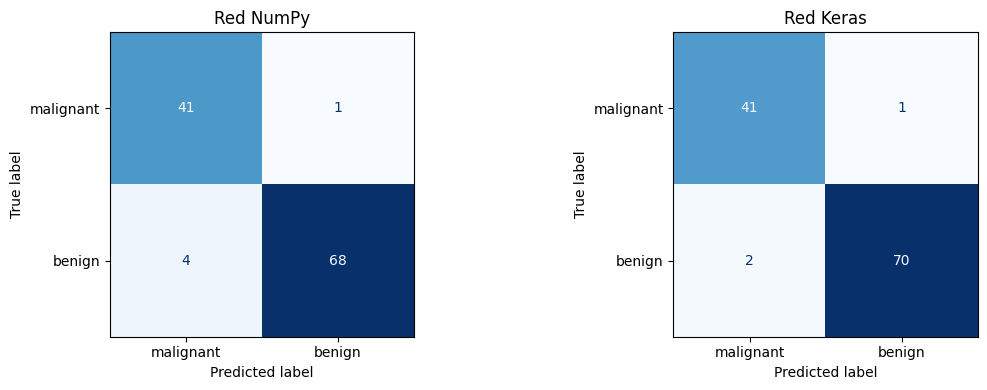

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_numpy, y_pred_keras],
    ['Red NumPy', 'Red Keras']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)

plt.tight_layout()
plt.show()

---
## Parte 3 — Experimentos (TODO)

### Experimento 1: Cambiar la arquitectura
Modifica `hidden_units` y `dropout_rate` en `build_model`. ¿Más capas siempre ayuda?

Pequeña [16]                   → Accuracy: 0.9474
Mediana [32, 16]               → Accuracy: 0.9649
Grande [128, 64, 32]           → Accuracy: 0.9561


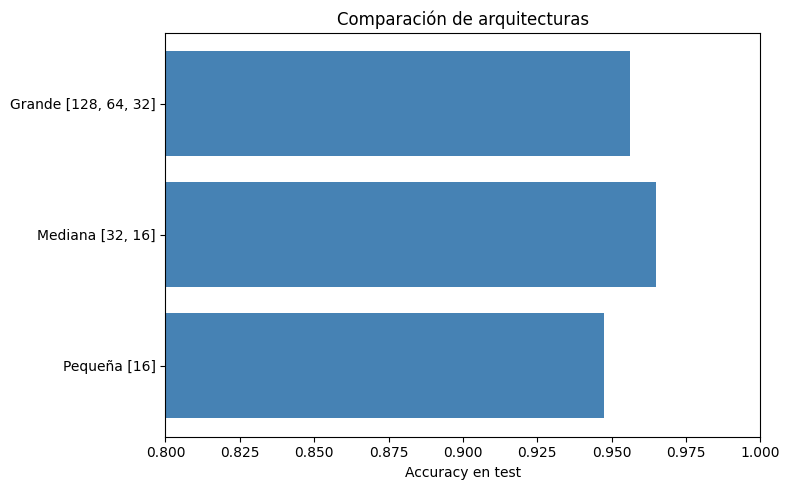

In [11]:
# TODO: Prueba al menos 3 arquitecturas diferentes y compara su accuracy en test
# Ejemplos:
#   [64]                    — red pequeña
#   [128, 64, 32]           — red más profunda
#   [16]  con dropout=0.5   — regularización fuerte

arquitecturas = {
    'Pequeña [16]':         [16],
    'Mediana [32, 16]':     [32, 16],
    'Grande [128, 64, 32]': [128, 64, 32],
}

resultados = {}

for nombre, capas in arquitecturas.items():
    m = build_model(X_train_s.shape[1], hidden_units=capas)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    m.fit(X_train_s, y_train, validation_split=0.2, epochs=100,
          callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
          verbose=0)
    _, acc = m.evaluate(X_test_s, y_test, verbose=0)
    resultados[nombre] = acc
    print(f'{nombre:30s} → Accuracy: {acc:.4f}')

# Gráfico comparativo
plt.barh(list(resultados.keys()), list(resultados.values()), color='steelblue')
plt.xlabel('Accuracy en test')
plt.title('Comparación de arquitecturas')
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

### Experimento 2: Diferentes optimizadores
Compara SGD, Adam y RMSprop en términos de velocidad de convergencia.

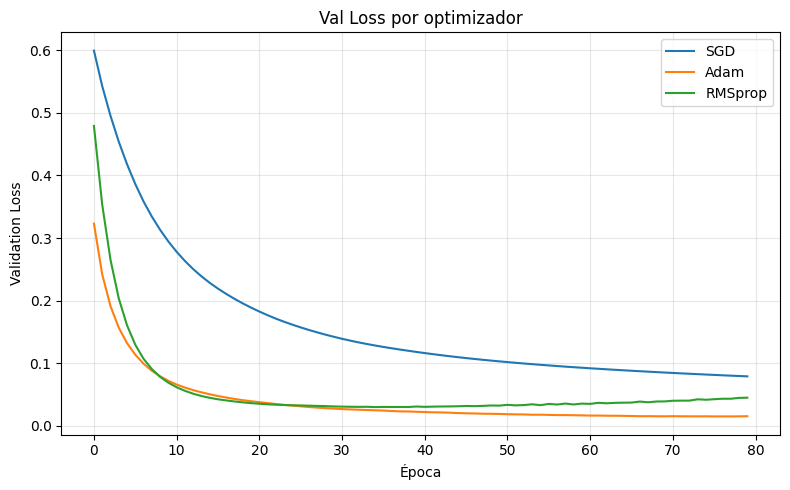

In [12]:
# TODO: Completa este experimento
optimizadores = {
    'SGD':     keras.optimizers.SGD(learning_rate=0.01),
    'Adam':    keras.optimizers.Adam(learning_rate=0.001),
    'RMSprop': keras.optimizers.RMSprop(learning_rate=0.001),
}

historias_opt = {}

for nombre, opt in optimizadores.items():
    m = build_model(X_train_s.shape[1], hidden_units=[32, 16], dropout_rate=0.0)
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X_train_s, y_train, validation_split=0.2, epochs=80, verbose=0)
    historias_opt[nombre] = h.history['val_loss']

for nombre, val_loss in historias_opt.items():
    plt.plot(val_loss, label=nombre)

plt.title('Val Loss por optimizador')
plt.xlabel('Época')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Experimento 3: Desafío — Dataset MNIST (clasificación multiclase)

Adapta el modelo para clasificar dígitos escritos a mano (0-9).

**Diferencias clave:**
- La entrada son imágenes 28×28 → debes aplanarlas a 784 features
- La salida son 10 clases → cambia la capa final a `Dense(10, activation='softmax')`
- El loss cambia a `sparse_categorical_crossentropy`

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)


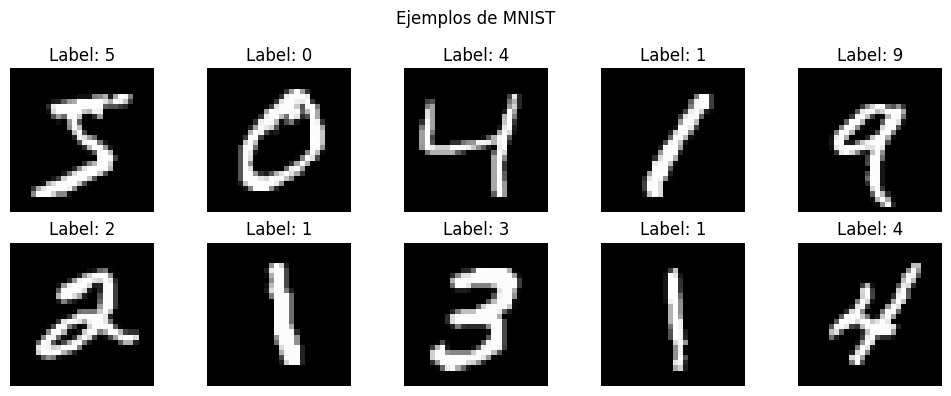

In [13]:
# Cargar MNIST
(X_mnist_train, y_mnist_train), (X_mnist_test, y_mnist_test) = keras.datasets.mnist.load_data()

print(f'Train: {X_mnist_train.shape}, Test: {X_mnist_test.shape}')

# Visualizar algunos dígitos
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_mnist_train[i], cmap='gray')
    ax.set_title(f'Label: {y_mnist_train[i]}')
    ax.axis('off')
plt.suptitle('Ejemplos de MNIST')
plt.tight_layout()
plt.show()

# TODO: Preprocesa los datos y construye una red para MNIST
# Pistas:
# 1. Normaliza dividiendo entre 255.0
# 2. Aplana: X_train.reshape(-1, 784)
# 3. Cambia la capa final a Dense(10, activation='softmax')
# 4. Usa loss='sparse_categorical_crossentropy'

# X_mnist_train_flat = ...
# X_mnist_test_flat  = ...
# model_mnist = ...